In [1]:
import sys
sys.path.append(r'../')
sys.path.append(r'../../include')
sys.path.append(r'../../bin/Release')
from netgen.occ import Cylinder, Z, OCCGeometry
from ngsolve import Mesh, TaskManager
from ngsolve.webgui import Draw
from netgen.webgui import Draw as DrawGeo
from Hiptmair_Problem import Hiptmair_Problem
from ngsolve import HCurl,H1, GridFunction, BilinearForm, curl, grad, dx, BND, LinearForm, Integrate, CF
import math

from MatrixSolver import MatrixSolver as solver 
cpp_solver="EMPY"
class Hiptmair_Proble_low_frequency(Hiptmair_Problem):
    def __init__(self):
        super().__init__()
        self.jomega=False
        True
        
    def Mesh(self,**kwargs):
        import netgen.meshing as ngmeshing
        default_values = {"curveOrder":2, }
        default_values.update(kwargs)
        self.curveOrder=default_values["curveOrder"]
        h=self.h
        r=self.b
        a=self.a
        curveOrder=self.curveOrder

        conductor = Cylinder((0,0,0), Z, r=0.01, h=h)
        conductor.faces.name="conductorBND"
        conductor.faces.Max(Z).name="out"
        conductor.faces.Min(Z).name="in"
        conductor.mat("sig")
        conductor.maxh=a/10
        crosssection = conductor.faces.Max(Z).mass

        model=conductor
        geo =OCCGeometry(model)
        with TaskManager():
            mesh = Mesh(geo.GenerateMesh(maxh=a/2)).Curve(1)
        
        self.sigma = mesh.MaterialCF({ "sig" : self.sig }, default=0)
        self.mesh=mesh
        return model, mesh

    def PrepareFESpace(self, feOrder=2, s0=2*math.pi):
        self.s0=s0
        self.feOrder=feOrder
        mesh = self.mesh
        jomega=self.jomega
        mu=self.mu
        sigma = self.sig
        self.fesA = HCurl(mesh, order=feOrder, nograds=True, dirichlet="out|in|conductorBND", complex=jomega)
        self.fesPhi = H1(mesh, order=feOrder, dirichlet="out|in|", complex=jomega) 
        self.fesAPhi=self.fesA*self.fesPhi
        (A,phi), (N, psi) = self.fesAPhi.TnT()
        
        mat=BilinearForm(self.fesAPhi)   
        mat += s0*sigma*(A+grad(phi))*(N+grad(psi))*dx("sig")
        mat += 1/mu*curl(A)*curl(N)*dx       
        with TaskManager():
            mat.Assemble()
        self.mat=mat 

    def InitialSolve(self):
        s0=self.s0
        jomega=self.jomega
        mu=self.mu
        sigma = self.sigma
        fesAPhi=self.fesAPhi
        (A,phi), (N, psi) = fesAPhi.TnT()
        gfAPhi = GridFunction(fesAPhi)
        gfA, gfPhi=gfAPhi.components

        V=1
        Vin=V/s0*self.h
        gfPhi.Set(Vin, BND, mesh.Boundaries("in"))
        f=LinearForm(fesAPhi)
        r=f.vec-self.mat.mat*gfAPhi.vec
        vec=r.Evaluate()
        logout=True
        gfAPhi, log=solver.iccg_solve(fesAPhi, gfAPhi, self.mat, vec, tol=1.e-20, max_iter=2000,
                    diviter=10, divfac=10., accel_factor=0,  complex=jomega, cpp_solver=cpp_solver, logplot=True, logout=logout, 
                    scaling=False)
        B=curl(gfA)
        E=-s0*(gfA+grad(gfPhi))
        return E, B 
  
    def Solve(self, Bin):
        s0=self.s0
        jomega=self.jomega
        mu=self.mu
        sigma = self.sigma
        fesAPhi=self.fesAPhi
        (A,phi), (N, psi) = fesAPhi.TnT()
        gfAPhi = GridFunction(fesAPhi)
        gfA, gfPhi=gfAPhi.components

        f=LinearForm(fesAPhi)
        f += 1/mu*Bin*curl(N)*dx 
        with TaskManager():
            f.Assemble()
        vec=f.vec.FV()
            
        logout=True
        gfAPhi, log=solver.iccg_solve(fesAPhi, gfAPhi, self.mat, vec, tol=1.e-20, max_iter=2000,
                         diviter=10, divfac=10., accel_factor=0,  complex=jomega, cpp_solver=cpp_solver, logplot=True, logout=logout, 
                        scaling=False)
        B=curl(gfA) - Bin
        E=-s0*(gfA+grad(gfPhi))
        return E, B 
        
    def Wj(self,E): 
        integ=Integrate(self.sigma *E*E*dx("sig"), self.mesh)/self.h
        return integ

    def Wm(self, B):
        integ=Integrate(1/self.mu*B*B*dx, self.mesh)/self.h
        return integ

    def Ranalytical(self, n):
        return (n+1)/(math.pi*self.a*self.a*self.sig)
    def Lanalytical(self, n):
        return mu/(4*math.pi)/(n+1)

    def Rcross(self,E1,B1, E2, B2):
        s0=self.s0
        integr=Integrate(self.sigma *E1*E2*dx("sig"), self.mesh)/self.h
        integl =s0*Integrate(1/self.mu*B1*B2*dx, self.mesh)/self.h
        lam=integr+integl
        #lam= 1./integr+1./integl
        return lam
        
    def Lcross(self,B1,B2):
        lam=Integrate(1/self.mu*B1*B2*dx, self.mesh)/self.h
        return lam

import numpy as np
import matplotlib.pyplot as plt

def plot_Dist(self, data, comp):
    # x軸（半径方向）のサンプリング点
    x_vals = np.linspace(0, self.a, 200)
    fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))

    # メッシュと固定座標の取得
    mesh = self.mesh
    z_fixed = self.h / 2
    y_fixed = 0.

    # --- 1. 電界 Ez のプロット (最大値 1 で規格化) ---
    if True:
        y_vals = []
        for x in x_vals:
            pnt = mesh(x, y_fixed, z_fixed)
            # E_dict[n] は CoefficientFunction と想定
            val = data(pnt)[comp]  # z成分
            y_vals.append(val)
        
        # リストをnumpy配列に変換して規格化
        y_vals = np.array(y_vals)
        max_v = np.max(np.abs(y_vals))

    print("max data=", max_v)
    y_plot = y_vals / max_v if max_v != 0 else y_vals   
    ax1.plot(x_vals, y_plot, label=f'$n={n}$')

    #ax1.set_title("Normalized Electric Field $E_z$ (Max=1)")
    ax1.set_xlabel("Radius $r$ [m]")
    ax1.set_ylabel("Relative Amplitude")
    ax1.set_ylim(-1.1, 1.1)
    ax1.grid(True, linestyle=':')
    #ax1.legend(loc='lower right', fontsize='x-small', ncol=2)

    plt.tight_layout()
    plt.show()
    
Hiptmair_Proble_low_frequency.plot_Dist = plot_Dist



WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.24…

ne= 32201
enter iccg_solve
Dof= 587764    Nonzeros= 51916950
shift parameter= 1.02
minimum residual= 6.891767251420606e-16  at iteraions:  143


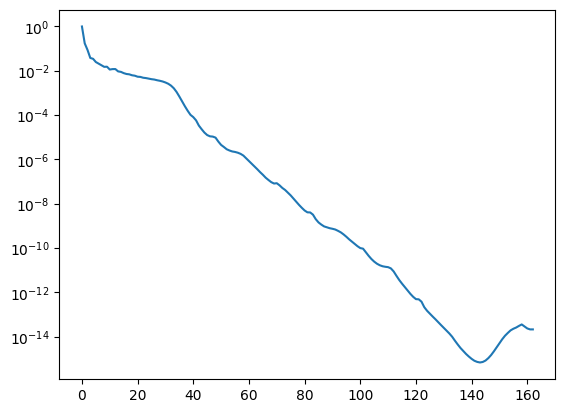

ICCG calculation time (sec): 31.934585400000287
R[0]= 0.015023991653152532
L[1]= 1.1190589545071267e-08
enter iccg_solve
Dof= 587764    Nonzeros= 51916950
shift parameter= 1.02
minimum residual= 7.75917963712363e-16  at iteraions:  141


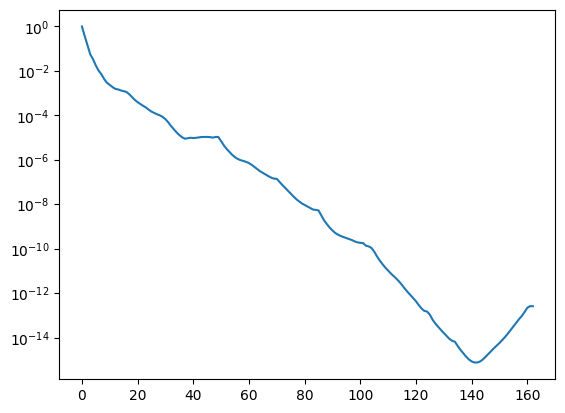

ICCG calculation time (sec): 33.06217590000051
R[2]= 0.028526049225561147
L[3]= 1.1119535566199626e-08
enter iccg_solve
Dof= 587764    Nonzeros= 51916950
shift parameter= 1.02
minimum residual= 5.701921487790881e-16  at iteraions:  141


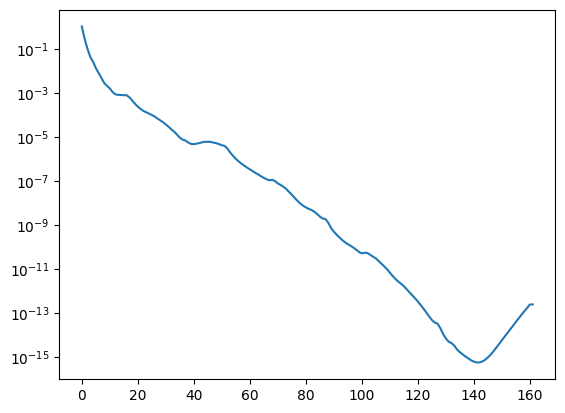

ICCG calculation time (sec): 31.636218100000406
R[4]= 0.028722500619197854
L[5]= 1.0853994671993214e-08
enter iccg_solve
Dof= 587764    Nonzeros= 51916950
shift parameter= 1.02
minimum residual= 5.772189650652013e-16  at iteraions:  141


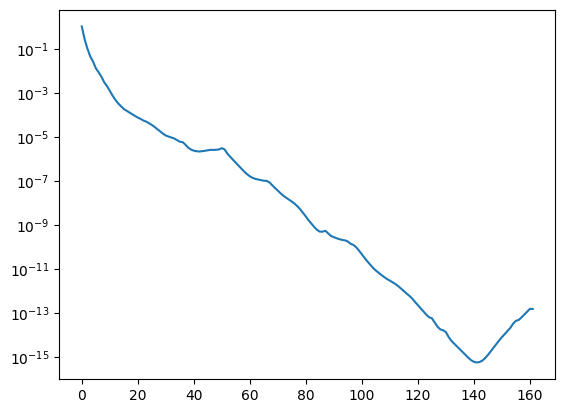

ICCG calculation time (sec): 31.339617699999508
R[6]= 0.0292483322776593
L[7]= 9.967954499749779e-09
enter iccg_solve
Dof= 587764    Nonzeros= 51916950
shift parameter= 1.02
minimum residual= 6.685396620790217e-16  at iteraions:  141


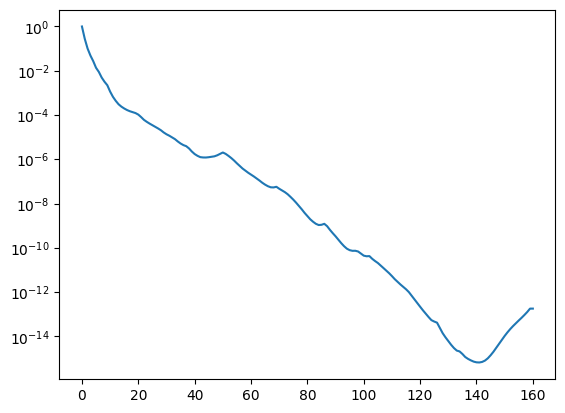

ICCG calculation time (sec): 31.118981300000087
R[8]= 0.030268033708883504


In [2]:
import sympy as sp
import math
sigma=1.e6
a=0.01
h=0.05
mu=4.e-7*math.pi
nmax=8
freq0=1.e5
s0=2*math.pi*freq0

HP= Hiptmair_Proble_low_frequency()
geo, mesh=HP.Mesh(curveOrder=3)
Draw(mesh)
print("ne=", mesh.ne)
HP.PrepareFESpace(feOrder=3, s0=s0)

E, B= {}, {}
R, L ={}, {}
Rratio={}
for n in range(0, nmax + 1, 2):
    if n==0:
        E[n], B[n]= HP.InitialSolve()
    else:    
        Btmp=B[n-1]/(s0*L[n-1])
        E[n], B[n]= HP.Solve(Btmp)
    if n>=2:
        E[n] += E[n-2]
        B[n] += B[n-2] 

    r=HP.Wj( E[n])
    sl=HP.Wm( B[n])*s0
    Rratio[n]=r/( sl + r )
    R[n]=1./( sl + r )
    print(f'R[{n}]=',R[n])

    n +=1
    if n > nmax: break
        
    B[n]=B[n-1]*R[n-1]
    if n>1: B[n]=B[n]+B[n-2]
    L[n]=HP.Wm(B[n])
    print(f'L[{n}]=',L[n])


In [3]:
from IPython.display import display, HTML, Markdown

# --- 3. IEEE レポート表示（HTML） ---
html_style = r"""
<style>
    .ieee-table {
        width: auto !important;
        border-collapse: collapse;
        font-family: "Times New Roman", serif;
        border-top: 2px solid black;
        border-bottom: 2px solid black;
        margin: 10px 0;
    }
    .ieee-table th, .ieee-table td {
        padding: 6px 15px;
        text-align: center;
        border-bottom: 1px solid #eee;
    }
    .ieee-table th { background-color: #f7f7f7; font-weight: bold; }
</style>
"""

# 文字列の先頭に r を付けて raw string とすることで、バックスラッシュをそのまま扱います
html_body = r'<table class="ieee-table"><thead><tr>'
html_body += r'<th>Symbol</th><th>Resistance [$\Omega$]</th>'
html_body += r'<th>Symbol</th><th>Inductance [H]</th>'
html_body += r'</tr></thead><tbody>'

for k in range(0, nmax + 1, 2):
    # R_k (偶数番目)
    r_sym = rf"R_{{{k}}}"
    r_val = sp.latex(R[k])
    
    # L_{k+1} (奇数番目) の存在チェック
    if k + 1 <= nmax:
        l_sym = rf"L_{{{k+1}}}"
        l_val = sp.latex(L[k+1])
    else:
        l_sym = ""
        l_val = ""

    # f-string の前にも r を付けて rf とします
    html_body += rf'''
    <tr>
        <td style="font-style: italic; background-color: #fcfcfc;">\( {r_sym} \)</td>
        <td style="text-align:left;">\( \displaystyle {r_val} \)</td>
        <td style="font-style: italic; background-color: #fcfcfc;">\( {l_sym} \)</td>
        <td style="text-align:left;">\( \displaystyle {l_val} \)</td>
    </tr>'''

html_body += r'</tbody></table>'

display(HTML(html_style + html_body))

Symbol,Resistance [$\Omega$],Symbol,Inductance [H]
\( R_{0} \),\( \displaystyle 0.0150239916531525 \),\( L_{1} \),\( \displaystyle 1.11905895450713 \cdot 10^{-8} \)
\( R_{2} \),\( \displaystyle 0.0285260492255611 \),\( L_{3} \),\( \displaystyle 1.11195355661996 \cdot 10^{-8} \)
\( R_{4} \),\( \displaystyle 0.0287225006191979 \),\( L_{5} \),\( \displaystyle 1.08539946719932 \cdot 10^{-8} \)
\( R_{6} \),\( \displaystyle 0.0292483322776593 \),\( L_{7} \),\( \displaystyle 9.96795449974978 \cdot 10^{-9} \)
\( R_{8} \),\( \displaystyle 0.0302680337088835 \),\( \),\( \displaystyle \)


f=1.e5    
FEOrder 1  
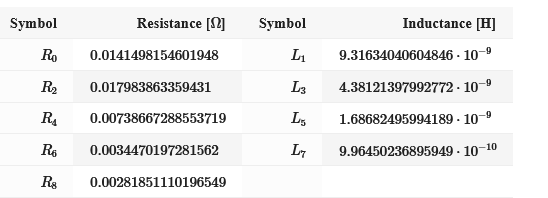


FEOrder 2  
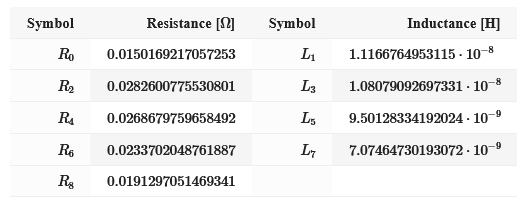


FEOrder 3    
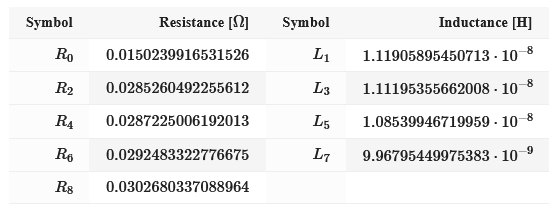

In [4]:
# Orthogonality
for n in range(0, nmax+1, 2):
    for m in range(0, n+1, 2):
        w= HP.Rcross( E[n],B[n], E[m], B[m])
        if w: print("n=", n, "m=", m, "w=", w)

for n in range(1, nmax+1, 2):
    for m in range(1, n+1, 2):
        w= HP.Lcross(B[n],B[m])
        if w:print("n=", n, "m=", m, "w=", w)


n= 0 m= 0 w= 66.56020737273019
n= 2 m= 0 w= -0.00023938055502270572
n= 2 m= 2 w= 35.05567813098831
n= 4 m= 0 w= 0.0012009084617617077
n= 4 m= 2 w= -0.003500466811290792
n= 4 m= 4 w= 34.81591012070896
n= 6 m= 0 w= -0.0016070500265257153
n= 6 m= 2 w= 0.0059460654372987245
n= 6 m= 4 w= -0.02496317519509006
n= 6 m= 6 w= 34.189983569211165
n= 8 m= 0 w= 0.023483308398905348
n= 8 m= 2 w= -0.014118483263040797
n= 8 m= 4 w= 0.022811630743676994
n= 8 m= 6 w= -0.10194606505974413
n= 8 m= 8 w= 33.038155356173846
n= 1 m= 1 w= 1.1190589545071267e-08
n= 3 m= 1 w= -3.461176094244522e-13
n= 3 m= 3 w= 1.1119535566199626e-08
n= 5 m= 1 w= 3.2203678407519597e-13
n= 5 m= 3 w= -3.699963037535049e-12
n= 5 m= 5 w= 1.0853994671993214e-08
n= 7 m= 1 w= -3.8956741075664065e-12
n= 7 m= 3 w= 6.16939241483587e-13
n= 7 m= 5 w= -1.7762672719188778e-11
n= 7 m= 7 w= 9.967954499749779e-09


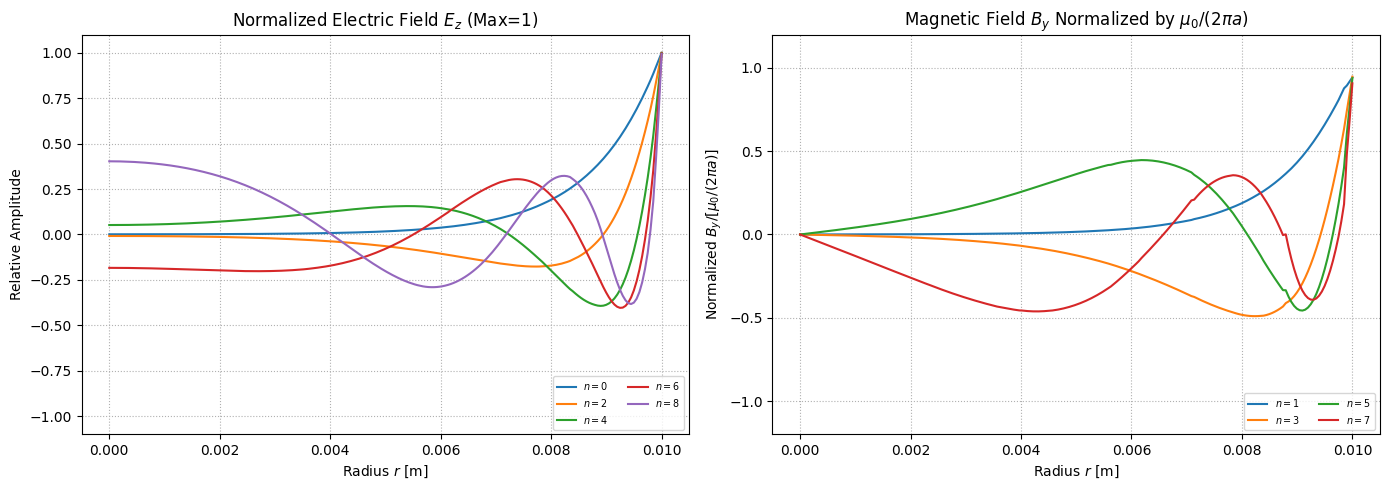

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_E_H(self, E_dict, B_dict):
    # x軸（半径方向）のサンプリング点
    x_vals = np.linspace(0, self.a, 200)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # メッシュと固定座標の取得
    mesh = self.mesh
    z_fixed = self.h / 2
    y_fixed = 0.

    # --- 1. 電界 Ez のプロット (最大値 1 で規格化) ---
    for n in sorted(E_dict.keys()):
        if n%2==0:
            y_vals = []
            for x in x_vals:
                pnt = mesh(x, y_fixed, z_fixed)
                # E_dict[n] は CoefficientFunction と想定
                val = E_dict[n](pnt)[2]  # z成分
        
                if self.jomega:
                    y_vals.append(val.real)
                else:
                    y_vals.append(val)
        
            # リストをnumpy配列に変換して規格化
            y_vals = np.array(y_vals)
            max_v = np.max(np.abs(y_vals))
            #y_plot = y_vals / max_v if max_v != 0 else y_vals
            y_plot = y_vals
            ax1.plot(x_vals, y_plot, label=f'$n={n}$')

    ax1.set_title("Normalized Electric Field $E_z$ (Max=1)")
    ax1.set_xlabel("Radius $r$ [m]")
    ax1.set_ylabel("Relative Amplitude")
    ax1.set_ylim(-1.1, 1.1)
    ax1.grid(True, linestyle=':')
    ax1.legend(loc='lower right', fontsize='x-small', ncol=2)

    # --- 2. 磁界 Ht の規格化プロット ---
    # 物理的な基準値 B_ref = mu * H_ref = mu * (1 / (2 * pi * a))
    b_ref_val = self.mu / (2 * np.pi * self.a)

    for n in sorted(B_dict.keys()):
        if n%2==1:
            y_vals = []
            for x in x_vals:
                pnt = mesh(x, y_fixed, z_fixed)
                val = B_dict[n](pnt)[1]  # Ht成分 (通常 y または theta 成分)
        
                if self.jomega:
                    y_vals.append(val.real)
                else:
                    y_vals.append(val)
        
            # リストをnumpy配列に変換（ここで TypeError を回避）
            y_norm = np.array(y_vals) / b_ref_val
        
            # z_vals が未定義だったので x_vals を使用
            ax2.plot(x_vals, y_norm, label=f'$n={n}$')

    ax2.set_title(r"Magnetic Field $B_y$ Normalized by $\mu_0 /(2\pi a)$")
    ax2.set_xlabel("Radius $r$ [m]")
    ax2.set_ylabel(r"Normalized $B_y / [\mu_0 /(2\pi a)]$")
    ax2.set_ylim(-1.2, 1.2)
    ax2.grid(True, linestyle=':')
    ax2.legend(loc='lower right', fontsize='x-small', ncol=2)


    plt.tight_layout()
    plt.show()

# メソッドの登録と実行
Hiptmair_Proble_low_frequency.plot_E_H = plot_E_H
HP.plot_E_H(E, B)

Freq=1.e5    
FEOrder 1   
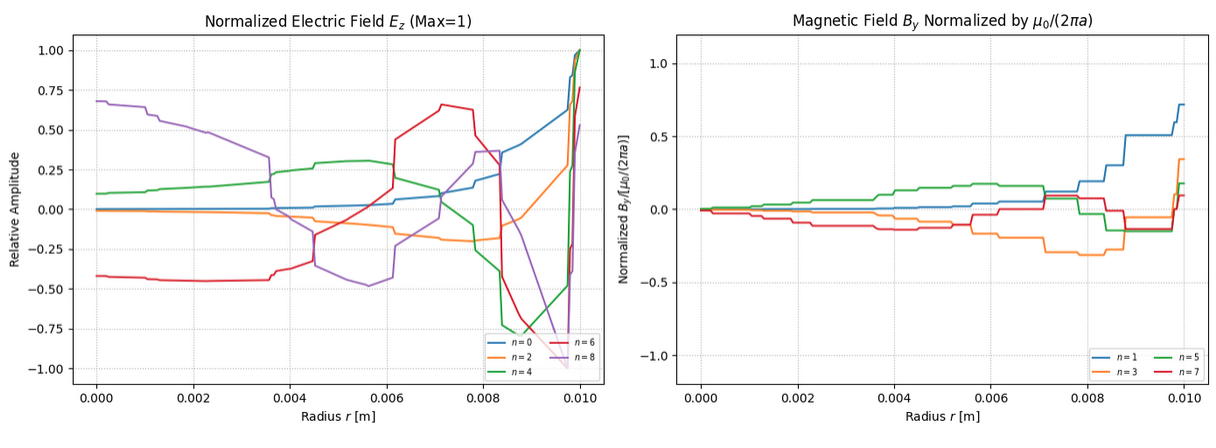

FEOrder 2   
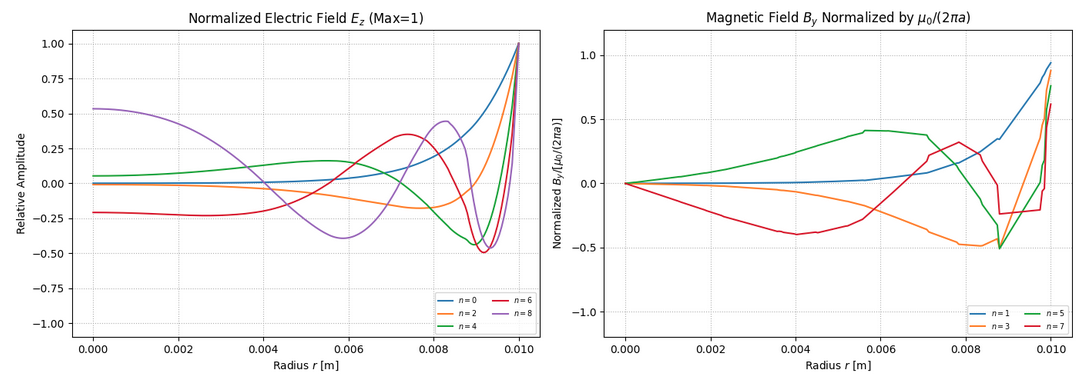

FEOrder 3
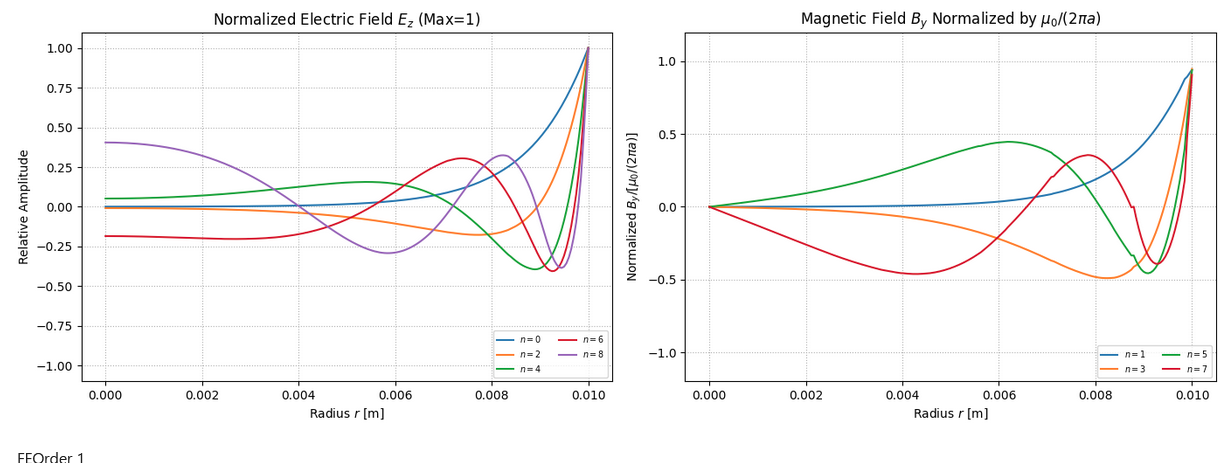

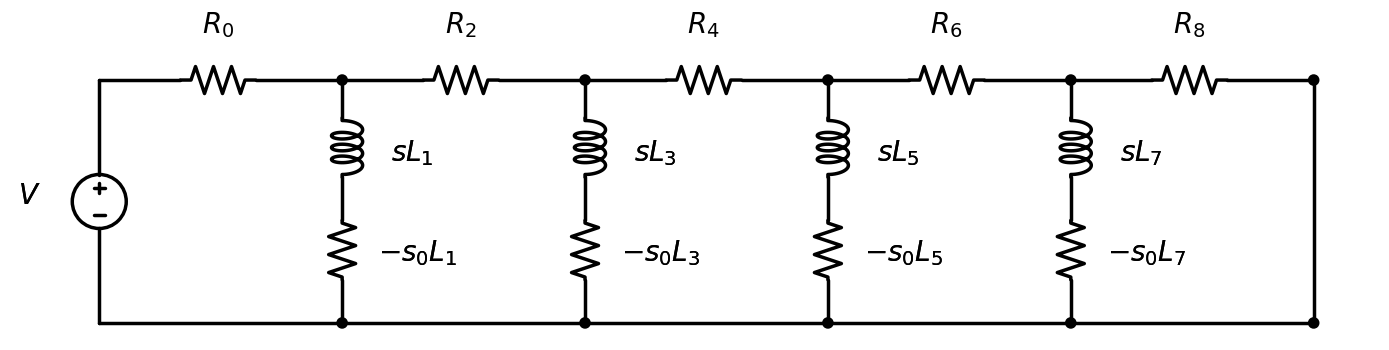

In [6]:
import matplotlib.pyplot as plt
import schemdraw
import schemdraw.elements as elm

def draw_Ladder_Curcuit(nmax=4):
    # IEEE論文用：フォント設定
    plt.rcParams["font.family"] = "serif"
    width = 2 + (nmax // 2) * 3
    fig = plt.figure(figsize=(width, 4)) 
    ax = fig.add_subplot(1, 1, 1)
    
    with schemdraw.Drawing(canvas=ax) as d:
        # unitを少し上げ、lw=2.5で線をより太く強調
        d.config(unit=1.4, fontsize=20, font='serif', lw=2.5)
        
        # ★ インダクタを劇的に太くする設定 ★
        # width=2.5 : 抵抗の数倍の幅を持たせ、圧倒的な存在感を出します
        # loops=2   : 巻きを大きく強調します
        L_STYLE = {'loops': 3, 'width': 2.5}
        
        YT, YB = 4.5, 0.0
        X_STEP = 4.5  # 横の間隔を十分に確保
        
        for i in range((nmax // 2) + 1):
            x, xi = i * X_STEP, (i + 1) * X_STEP
            
            # --- 横方向の抵抗 ---
            if 2*i <= nmax:
                d.add(elm.Line().at((x, YT)).length(1.5))
                d.add(elm.Resistor().length(1.4).label(f'$R_{{{2*i}}}$', loc='top', ofst=0.5))
                d.add(elm.Line().to((xi, YT)).dot())

                """
                x1=x+0.7
                d.add(elm.Line().at((x1, YT)).to((x1, YT + 1.2)))  
                d.add(elm.Line().at((x1, YT + 1.2)).length(0.8))
                d.add(elm.Inductor().length(1.4).label(f'$-R_{{{2*i}}}/s_0$', loc='top', ofst=0.7))
                """
            # --- 縦方向の枝 (sLn, -s0Ln) ---
            idx_l = 2*i + 1
            if idx_l <= nmax:
                # 上部との接続
                d.add(elm.Line().at((xi, YT)).to((xi, YT - 0.7)))
                
                # インダクタ (sLn) - ラベルを右側へ離す
                d.add(elm.Inductor2(**L_STYLE).length(1.1).down())
                d.add(elm.Label(label=f'$s L_{{{idx_l}}}$').at((xi + 1.2, YT - 1.25)))
                
                # 素子間の接続線（長さを確保）
                d.add(elm.Line().length(0.8).down())
                
                # 抵抗 (-s0Ln) - ラベルを右側へ離す
                d.add(elm.Resistor().length(1.1).down())
                d.add(elm.Label(label=f'$-s_0 L_{{{idx_l}}}$').at((xi + 1.3, YT - 3.1)))
                
                d.add(elm.Line().to((xi, YB)).dot())
            elif 2*i == nmax:
                # 終端
                d.add(elm.Line().at((xi, YT)).to((xi, YB)).dot())

            # 下側の配線
            d.add(elm.Line().at((x, YB)).to((xi, YB)))
            
        # --- 電源 V の配置 (重なり回避) ---
        # 始点 (0, YB) から 終点 (0, YT) へ
        d.add(elm.SourceV().at((0, YB)).to((0, YT)))
        # at=(-1.2, YT/2) : 電源記号の左側に大きくオフセットを取ります
        d.add(elm.Label(label='$V$').at((-1.2, YT/2)))

    ax.set_aspect('equal')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

# 実行
draw_Ladder_Curcuit(nmax=8)

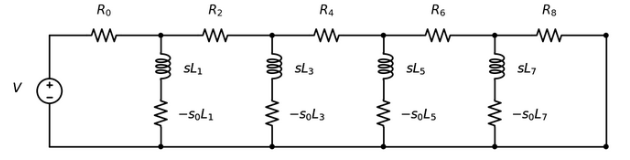

FEOrder 3    
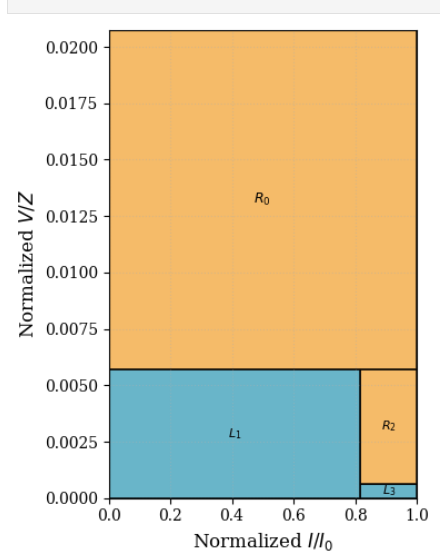

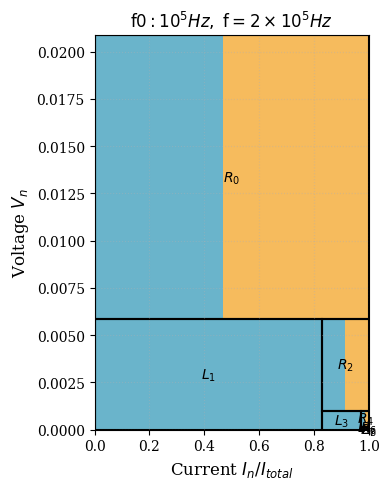

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_impedance_map_R0_top(self, R_dict, L_dict, Rratio, nmax, s_input=1.0):
    plt.rcParams["font.family"] = "serif"
    fig = plt.figure(figsize=(4, 5))
    ax_map = fig.add_subplot(1, 1, 1)
    
    color_l, color_r = '#50A7C2', '#F5B041'
    fac = (s_input - self.s0) / s_input

    shapes_raw = []        
    frame_rects = []       
    labels_with_pos = []   

    # --- マップ計算ロジック ---
    val_nmax = R_dict[nmax] if nmax % 2 == 0 else L_dict[nmax]
    ar_nmax = val_nmax * s_input*fac if nmax % 2 != 0 else val_nmax
    curr_w, curr_h = 1.0, ar_nmax
    x0, y0 = 0, 0
    
    label_nmax = f"$L_{{{nmax}}}$" if nmax % 2 != 0 else f"$R_{{{nmax}}}$"

    # 初期ブロック
    if nmax % 2 != 0: 
        # 奇数：分割なし（例：青で統一）
        shapes_raw.append((x0, y0, curr_w, ar_nmax, color_l, ""))
    else: 
        # 偶数：左右分割
        w_orange = curr_w * Rratio[nmax]
        w_blue = curr_w * (1 - Rratio[nmax])
        shapes_raw.append((x0, y0, w_blue, curr_h, color_l, ""))
        shapes_raw.append((x0 + w_blue, y0, w_orange, curr_h, color_r, ""))
    
    frame_rects.append((x0, y0, curr_w, ar_nmax))
    labels_with_pos.append((x0, y0, curr_w, ar_nmax, label_nmax))

    for n in range(nmax - 1, -1, -1):
        val = R_dict[n] if n % 2 == 0 else L_dict[n]
        if n % 2 == 0: # 偶数：左右分割
            w_orange = curr_w * Rratio[n]
            w_blue = curr_w * (1 - Rratio[n])
            shapes_raw.append((x0, y0 + curr_h, w_blue, val * curr_w, color_l, ""))
            shapes_raw.append((x0 + w_blue, y0 + curr_h, w_orange, val * curr_w, color_r, ""))
            frame_rects.append((x0, y0 + curr_h, curr_w, val * curr_w))
            labels_with_pos.append((x0, y0 + curr_h, curr_w, val * curr_w, f"$R_{{{n}}}$"))
            curr_h += val * curr_w
        else: # 奇数：分割なし
            w_L = curr_h / (val * s_input*fac)
            x0 -= w_L
            shapes_raw.append((x0, y0, w_L, curr_h, color_l, ""))
            frame_rects.append((x0, y0, w_L, curr_h))
            labels_with_pos.append((x0, y0, w_L, curr_h, f"$L_{{{n}}}$"))
            curr_w += w_L
            
    # --- 描画処理 ---
    # 塗りつぶし
    for x, y, w, h, c, label in shapes_raw:
        nx, ny, nw, nh = (x - x0)/curr_w, y/curr_w, w/curr_w, h/curr_w
        ax_map.add_patch(patches.Rectangle((nx, ny), nw, nh, facecolor=c, edgecolor='none', alpha=0.85))

    # ラベルと外枠
    for x, y, w, h, label in labels_with_pos:
        nx, ny, nw, nh = (x - x0)/curr_w, y/curr_w, w/curr_w, h/curr_w
        if label:
            ax_map.text(nx + nw/2, ny + nh/2, label, ha='center', va='center', fontsize=10, fontweight='bold')
    for x, y, w, h in frame_rects:
        nx, ny, nw, nh = (x - x0)/curr_w, y/curr_w, w/curr_w, h/curr_w
        ax_map.add_patch(patches.Rectangle((nx, ny), nw, nh, facecolor='none', edgecolor='black', lw=1.5))

    ax_map.set_xlim(0, 1.0)
    ax_map.set_ylim(0, curr_h / curr_w)
    ax_map.set_xlabel("Current $I_n / I_{total}$", fontsize=12)
    ax_map.set_ylabel("Voltage $V_n $", fontsize=12)
    ax_map.grid(True, linestyle=':', alpha=0.4)
    ax_map.set_title(r"$\text{f0}: 10^5 Hz, \text{ f}=2 \times 10^5Hz$")
    
    plt.tight_layout()
    plt.show()

Hiptmair_Proble_low_frequency.draw_impedance_map_R0_top = draw_impedance_map_R0_top
#nmax=3
HP.draw_impedance_map_R0_top(R, L, Rratio, nmax=nmax, s_input=2*s0)

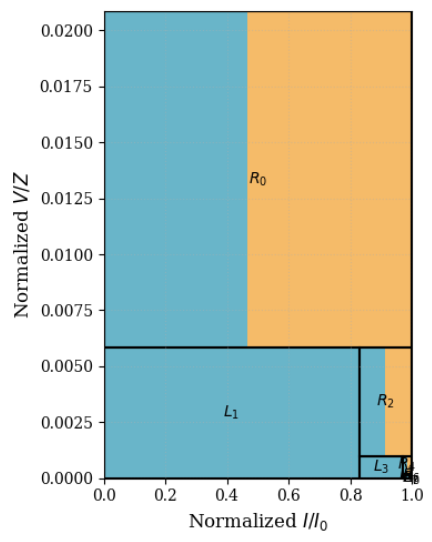

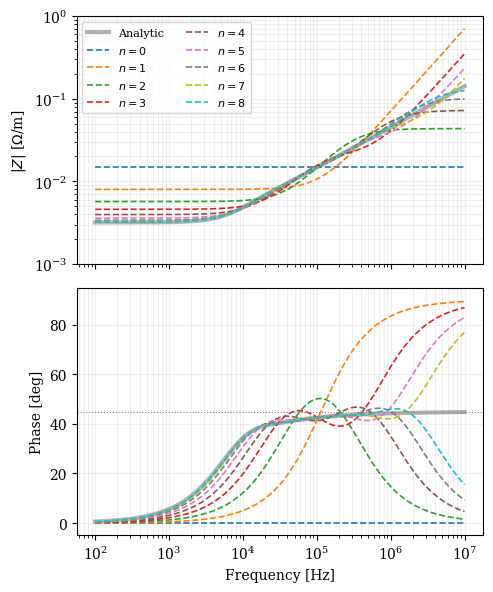

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv
import sympy as sp
import math

# --- 1. 理論パラメータ生成 ---
#a_sym, mu_sym, sigma_sym = sp.symbols('a mu sigma', real=True, positive=True)


# --- 2. プロット実行関数 ---
def run_comparison(self, R, L, nmax_list, s_complex):
    #s_complex=False
    nmax = max(nmax_list)
    mu_val = 4 * math.pi * 1e-7
    a_val=self.a
    sigma_val=self.sig

    
    # 辞書として数値パラメータを取得
    r_num, l_num = R, L
    
    freqs = np.logspace(2, 7, 500)
    omega = 2 * np.pi * freqs
    
    # 厳密解 (Bessel関数)
    def analytic_z(s, a=a_val, mu=mu_val, sigma=sigma_val):
        b=0.1
        if s_complex:
            k = np.sqrt(-s * mu * sigma)
        else:
            k = 1j*np.sqrt(s * mu * sigma)
        ka = k * a
        # インピーダンス Z = (k / 2pi*a*sigma) * J0(ka)/J1(ka)
        z = (k / (2 * np.pi * a * sigma)) * (jv(0, ka) / jv(1, ka))
        #z += mu*math.log(b/a)/(2*math.pi)*s
        return z

    if s_complex:
        z_analytic = np.array([analytic_z(1j*w) for w in omega])
    else:
        z_analytic = np.array([analytic_z(w) for w in omega])
        
    # プロット設定
    if s_complex:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6), sharex=True)
    else:
        fig, (ax1) = plt.subplots(1, 1, figsize=(5, 4), sharex=True)
    plt.rcParams["font.size"] = 9

    # 厳密解の描画
    if s_complex:
        ax1.loglog(freqs, np.abs(z_analytic), 'k', lw=3, label='Analytic', alpha=0.3)
        ax2.semilogx(freqs, np.angle(z_analytic, deg=True), 'k', lw=3, label='Exact', alpha=0.3)
    else:
        ax1.loglog(freqs, z_analytic.real, 'k', lw=3, label='Analytic', alpha=0.3)
        
    #cmap = plt.get_cmap('jet')
    #cmap = plt.get_cmap('Spectral')
    cmap = plt.get_cmap('tab10')
    
    #colors = [cmap(i) for i in np.linspace(0, 0.9, len(nmax_list))]
    colors = [cmap(i) for i in np.linspace(0, 1.0, len(nmax_list))]

    # 梯子型回路の計算

    #r_num[2]=0.03*1.27
    #r_num[2] =r_num[2]
    #r_num[2] =0.009549296585513718
    #print(r_num[2])
    for nm, col in zip(nmax_list, colors):
        def calculate_z(s, current_n):
            fac=(s-self.s0)/s
            # 再帰的または逆順ループで連分数形式を計算
            # 末端のインピーダンスから順に合成していく
            if current_n % 2 == 0:
                z = r_num[current_n]
                #z = r_num[current_n]
            else:
                z = s * l_num[current_n]*fac
                
            for i in range(current_n - 1, -1, -1):
                if i % 2 == 0:
                    z = r_num[i] + z # 直列抵抗
                else:
                    z_ind = s * l_num[i]*fac
                    z = 1 / (1/z_ind + 1/z) # 並列インダクタンス
            return z
        if s_complex: 
            z_ladder = np.array([calculate_z(1j*w, nm) for w in omega])
            ax1.loglog(freqs, np.abs(z_ladder), color=col, ls='--', lw=1.2, label=fr'$n={nm}$')
            ax2.semilogx(freqs, np.angle(z_ladder, deg=True), color=col, ls='--', lw=1.2, label=fr'$n={nm}$')
        else:
            z_ladder = np.array([calculate_z(w, nm) for w in omega])
            ax1.loglog(freqs, z_ladder.real, color=col, ls='--', lw=1.2, label=fr'$n={nm}$')


    # 装飾
    ax1.set_ylabel(r'$|Z|$ [$\Omega$/m]', fontsize=10)
    ax1.legend(ncol=2, fontsize=8, frameon=True, loc='best')
    ax1.grid(True, which="both", ls="-", alpha=0.2)
    ax1.set_ylim(1.e-3, 1)
    
    if s_complex:
        ax2.set_ylabel('Phase [deg]', fontsize=10)
        ax2.set_xlabel('Frequency [Hz]', fontsize=10)
        ax2.set_ylim(-5, 95)
        ax2.axhline(45, color='gray', lw=0.8, ls=':')
        ax2.grid(True, which="both", ls="-", alpha=0.2)

    plt.tight_layout()
    plt.show()

# 実行
Hiptmair_Proble_low_frequency.run_comparison = run_comparison
n_list = list(range(nmax + 1))
HP.run_comparison(R, L, nmax_list=n_list, s_complex=True)

FEOrder 1    
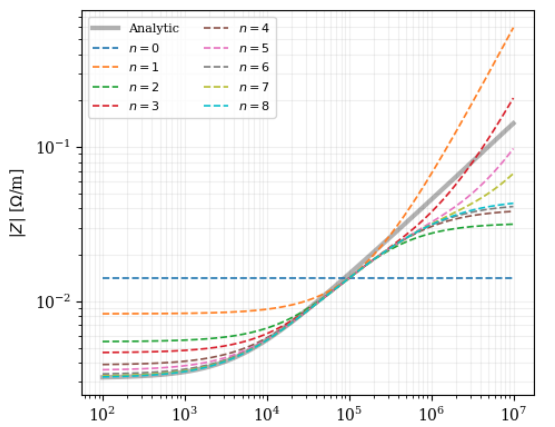

FEOrder 2    
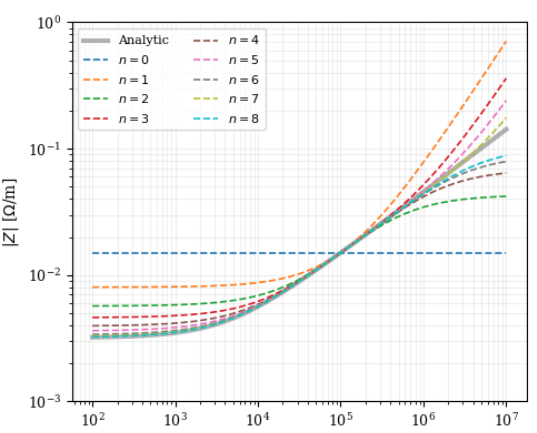

FEOrder 3    
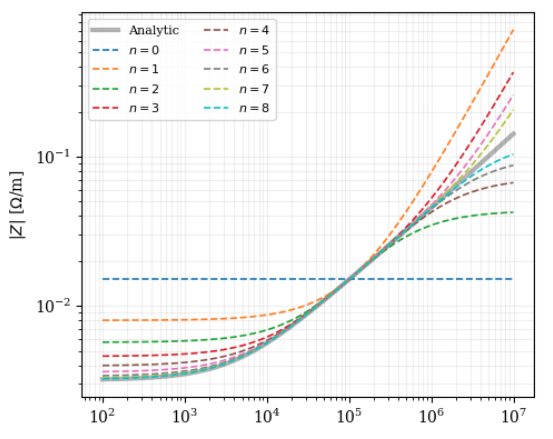
